
Ridge and lasso are the two workhorse methods for fitting a linear model when you have many predictors, some of them correlated, and ordinary least squares (OLS) starts to behave badly. Both add a penalty term to the regression objective; they differ in exactly one detail — whether that penalty is squared or absolute — and that single difference changes everything about how the two methods behave.

This tutorial builds both from scratch: the math, the geometry behind why lasso zeroes out coefficients and ridge doesn't, and a full R implementation of each, checked against closed-form solutions and OLS along the way.



# Why Plain Linear Regression Breaks Down

> **If OLS already minimizes the residual sum of squares, why would we want anything else?**
> Because "minimizes the training residual" and "gives a trustworthy, stable estimate" are not the same promise. OLS keeps that promise only when predictors are roughly independent and there's plenty of data relative to the number of predictors. Neither is guaranteed in practice.

Real predictor sets are rarely independent. Two variables measuring related things — income and years of education, or two neighboring genetic markers in the same region of a chromosome — carry overlapping information. When predictors are highly correlated, OLS has to arbitrarily decide how to split credit between them, and that split is extremely sensitive to the specific noise in your sample.

We can see this directly. Simulate a 10-predictor design with two "correlated blocks" of 4 predictors each (correlation 0.85 within each block) plus 2 independent predictors, only three of which actually affect the outcome.


In [1]:
set.seed(42)

## Build a 10-predictor design matrix with two correlated "LD-like" blocks
## of 4 predictors each (within-block correlation 0.85) plus 2 independent
## noise predictors -- deliberately mimicking correlated genotype blocks.
p <- 10
n <- 200

Sigma <- diag(p)
block1 <- 1:4; block2 <- 5:8
Sigma[block1, block1] <- 0.85
Sigma[block2, block2] <- 0.85
diag(Sigma) <- 1

## Sample correlated predictors via the Cholesky factor of Sigma
L <- chol(Sigma)
Z <- matrix(rnorm(n * p), n, p)
X <- Z %*% L
X <- scale(X)                      # standardize columns
colnames(X) <- paste0("X", 1:p)

## True effects: only the first predictor in each correlated block, plus
## one of the independent noise predictors, actually affect the outcome
true_beta <- c(3, 0, 0, 0, -2, 0, 0, 0, 1.5, 0)
y <- as.vector(X %*% true_beta + rnorm(n, sd = 3))

cat("Correlation within block 1 (X1-X4):\n")
print(round(cor(X[, block1]), 2))
cat("\nTrue beta:", true_beta, "\n")

saveRDS(list(X = X, y = y, true_beta = true_beta, Sigma = Sigma), "reg_data.rds")

Correlation within block 1 (X1-X4):
     X1   X2   X3   X4
X1 1.00 0.85 0.82 0.84
X2 0.85 1.00 0.84 0.85
X3 0.82 0.84 1.00 0.84
X4 0.84 0.85 0.84 1.00

True beta: 3 0 0 0 -2 0 0 0 1.5 0 



X1–X4 and X5–X8 form two tight correlated blocks, exactly the kind of structure that causes trouble. Only X1, X5, and X9 have a real effect on the outcome — everything else is either a correlated "twin" of a real predictor, or pure noise.



## 1.1 OLS instability under correlated predictors

Refit OLS 300 times on fresh draws of the outcome (same design matrix each time) and look at how much the estimated coefficients bounce around.


In [2]:
sim <- readRDS("reg_data.rds")
X <- sim$X; true_beta <- sim$true_beta
n <- nrow(X); p <- ncol(X)

set.seed(1)
B <- 300
ols_coefs <- matrix(NA, B, p)
for (b in seq_len(B)) {
  y_b <- as.vector(X %*% true_beta + rnorm(n, sd = 3))   # fresh noise draw, same X
  ols_coefs[b, ] <- coef(lm(y_b ~ X - 1))
}
colnames(ols_coefs) <- colnames(X)

cat("Standard deviation of OLS estimates for each predictor:\n")
print(round(apply(ols_coefs, 2, sd), 2))

Standard deviation of OLS estimates for each predictor:
  X1   X2   X3   X4   X5   X6   X7   X8   X9  X10 
0.49 0.51 0.46 0.52 0.52 0.52 0.55 0.52 0.21 0.22 



The correlated-block predictors (X1–X8) have roughly double the standard deviation of the independent ones (X9, X10) — 0.5 versus 0.2 — purely because of correlation, not because they're individually less informative. OLS is unbiased here (the boxes are centered near the true values), but "unbiased and wildly variable" is not a comforting property when you're trying to trust a specific estimate from a specific sample.

Regularization trades away a little of that unbiasedness in exchange for a large reduction in variance — a good trade whenever variance is the bigger problem, which it usually is with correlated or high-dimensional predictors.



# Ridge Regression: Shrinking with an L2 Penalty

> **What does ridge regression actually change about the objective function?**
> It adds a penalty proportional to the *squared* size of the coefficients, so the optimizer is rewarded for keeping them small, not just for fitting the training data.

$$
\hat\beta_{\text{ridge}} = \arg\min_\beta \left\{ \sum_{i=1}^n (y_i - x_i^\top\beta)^2 + \lambda\sum_{j=1}^p \beta_j^2 \right\}
$$

$\lambda \ge 0$ controls the strength of the penalty: $\lambda=0$ recovers plain OLS, and as $\lambda\to\infty$ every coefficient is forced toward zero. Because the penalty is smooth and quadratic, this objective has a closed-form solution:

$$
\hat\beta_{\text{ridge}} = (X^\top X + \lambda I)^{-1}X^\top y
$$

Compare this to the OLS solution, $\hat\beta_{\text{OLS}} = (X^\top X)^{-1}X^\top y$: ridge simply adds $\lambda$ to the diagonal of $X^\top X$ before inverting. This is precisely the fix for the numerical instability that correlated predictors cause — $X^\top X$ becomes close to singular (nearly non-invertible) when columns are highly correlated, and adding $\lambda I$ keeps it comfortably invertible (this is why ridge is sometimes called Tikhonov regularization, its original name in the applied-math literature).


In [3]:
sim <- readRDS("reg_data.rds")
X <- sim$X; y <- sim$y; true_beta <- sim$true_beta
n <- nrow(X); p <- ncol(X)

ridge_fit <- function(X, y, lambda) {
  p <- ncol(X)
  solve(t(X) %*% X + lambda * diag(p), t(X) %*% y)
}

lambda_grid <- exp(seq(log(0.01), log(500), length.out = 60))
ridge_path <- t(sapply(lambda_grid, function(l) ridge_fit(X, y, l)))
colnames(ridge_path) <- colnames(X)

## Sanity check against the OLS solution as lambda -> 0
cat("Ridge at lambda~0     :", round(ridge_path[1, ], 3), "\n")
cat("OLS (lm)              :", round(coef(lm(y ~ X - 1)), 3), "\n")

saveRDS(list(lambda_grid = lambda_grid, ridge_path = ridge_path), "ridge_path.rds")

Ridge at lambda~0     : 2.808 -0.636 0.445 0.293 -1.273 -0.078 -0.88 0.226 1.832 0.307 
OLS (lm)              : 2.809 -0.636 0.445 0.293 -1.273 -0.078 -0.88 0.226 1.832 0.307 



As it must: with $\lambda$ essentially at zero, ridge and OLS agree to three decimal places. Now trace out the full path as $\lambda$ grows.


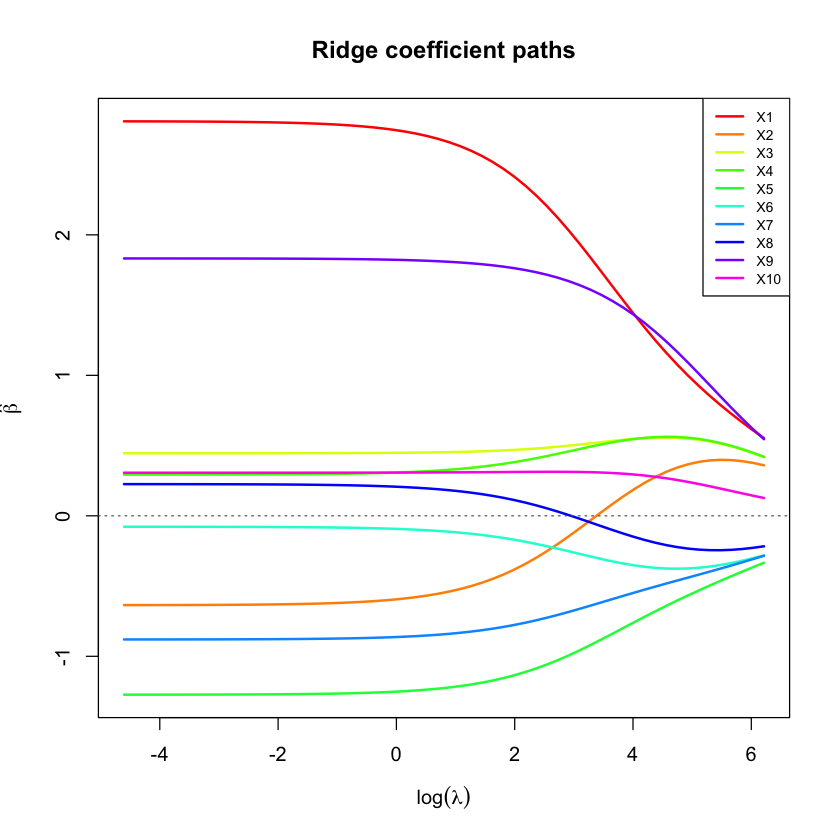

In [4]:
p <- ncol(X)
matplot(log(lambda_grid), ridge_path, type = "l", lty = 1, lwd = 2,
        col = rainbow(p, end = 0.85),
        xlab = expression(log(lambda)), ylab = expression(hat(beta)),
        main = "Ridge coefficient paths")
abline(h = 0, lty = 3, col = "grey40")
legend("topright", legend = colnames(X), col = rainbow(p, end = 0.85), lty = 1, lwd = 2, cex = 0.7)


Every coefficient shrinks smoothly and continuously toward zero as $\lambda$ increases, but none of them ever actually *reach* zero (except in the limit). That single observation — smooth shrinkage, never exactly zero — is the entire practical difference between ridge and lasso, and it comes directly from using a squared penalty instead of an absolute one. We'll see exactly why in the geometry section below.



# Lasso: An L1 Penalty and the Sparsity It Creates

Lasso (Tibshirani, 1996) replaces the squared penalty with an absolute one:

$$
\hat\beta_{\text{lasso}} = \arg\min_\beta \left\{ \sum_{i=1}^n (y_i - x_i^\top\beta)^2 + \lambda\sum_{j=1}^p |\beta_j| \right\}
$$

> **Why doesn't this have a closed-form solution the way ridge does?**
> The absolute value function isn't differentiable at zero. Calculus-based closed forms rely on setting a smooth derivative to zero everywhere; lasso's objective has a kink exactly where the interesting behavior (a coefficient becoming zero) happens.

Instead, lasso is solved iteratively. **Coordinate descent** (Friedman, Hastie & Tibshirani, 2010) optimizes one coefficient at a time, holding all others fixed, and cycles through all predictors repeatedly until nothing changes. Fixing every $\beta_k$ for $k \ne j$, the one-dimensional update for $\beta_j$ turns out to be a simple **soft-thresholding** operation:

$$
\hat\beta_j \leftarrow \frac{S\left(\sum_i x_{ij}\left(y_i - \sum_{k\ne j} x_{ik}\beta_k\right),\; n\lambda/2\right)}{\sum_i x_{ij}^2}, \qquad S(z,\gamma) = \text{sign}(z)\max(|z|-\gamma,\ 0)
$$

$S$ shrinks its input toward zero by $\gamma$, and clips it to exactly zero if the input wasn't larger than $\gamma$ to begin with. That clipping-to-exactly-zero step is where lasso's sparsity comes from — it's baked directly into the per-coordinate update rule.


In [5]:
soft_threshold <- function(z, gamma) sign(z) * pmax(abs(z) - gamma, 0)

lasso_fit <- function(X, y, lambda, tol = 1e-8, max_iter = 5000) {
  p <- ncol(X); n <- nrow(X)
  beta <- rep(0, p)
  Xy <- t(X) %*% y
  XtX <- t(X) %*% X

  for (iter in seq_len(max_iter)) {
    beta_old <- beta
    for (j in seq_len(p)) {
      r_j <- Xy[j] - sum(XtX[j, -j] * beta[-j])
      beta[j] <- soft_threshold(r_j, n * lambda / 2) / XtX[j, j]
    }
    if (max(abs(beta - beta_old)) < tol) break
  }
  beta
}

## Verify the coordinate-descent update against the univariate closed form:
## for a single predictor (no correlated neighbours), lasso reduces to soft-
## thresholding the OLS coefficient directly.
x1 <- X[, 1]
beta_ols_uni <- sum(x1 * y) / sum(x1^2)
lambda_test <- 0.3
beta_lasso_uni <- soft_threshold(sum(x1 * y), n * lambda_test / 2) / sum(x1^2)
cat("Univariate OLS beta          :", round(beta_ols_uni, 4), "\n")
cat("Univariate soft-thresholded  :", round(beta_lasso_uni, 4), "\n\n")

lambda_grid <- exp(seq(log(0.005), log(3), length.out = 60))
lasso_path <- t(sapply(lambda_grid, function(l) lasso_fit(X, y, l)))
colnames(lasso_path) <- colnames(X)

cat("Lasso at lambda~0 (should match OLS):", round(lasso_path[1, ], 3), "\n")
cat("OLS (lm)                             :", round(coef(lm(y ~ X - 1)), 3), "\n")

saveRDS(list(lambda_grid = lambda_grid, lasso_path = lasso_path), "lasso_path.rds")

Univariate OLS beta          : 2.9352 
Univariate soft-thresholded  : 2.7844 

Lasso at lambda~0 (should match OLS): 2.8 -0.614 0.434 0.289 -1.267 -0.067 -0.868 0.199 1.831 0.305 
OLS (lm)                             : 2.809 -0.636 0.445 0.293 -1.273 -0.078 -0.88 0.226 1.832 0.307 



Both checks hold: the univariate soft-thresholded estimate is a shrunken version of the univariate OLS estimate (2.78 vs. 2.94, exactly what soft-thresholding by a positive amount should do), and the full multivariate lasso path recovers OLS almost exactly as $\lambda\to0$. Now the path itself:


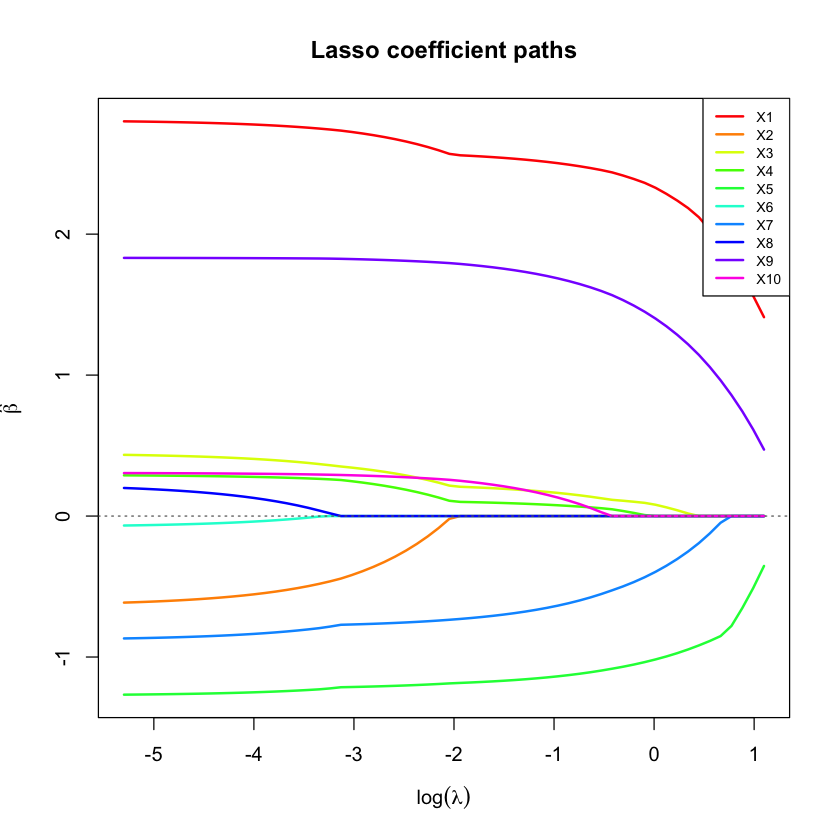

In [6]:
p <- ncol(X)
matplot(log(lambda_grid), lasso_path, type = "l", lty = 1, lwd = 2,
        col = rainbow(p, end = 0.85),
        xlab = expression(log(lambda)), ylab = expression(hat(beta)),
        main = "Lasso coefficient paths")
abline(h = 0, lty = 3, col = "grey40")
legend("topright", legend = colnames(X), col = rainbow(p, end = 0.85), lty = 1, lwd = 2, cex = 0.7)


This is the signature lasso picture: coefficients don't just shrink, they drop to *exactly* zero, one by one, in a staircase pattern as $\lambda$ increases. Compare this directly to the ridge path above — same data, same $\lambda$ range in spirit, completely different qualitative behavior.



# The Geometry Behind Why Lasso Zeroes Out Coefficients

Both penalized objectives have an equivalent "constrained optimization" formulation: minimize the residual sum of squares subject to a budget on the total penalty. For lasso, the budget is on $\sum|\beta_j|$ — geometrically, a **diamond** (in two dimensions) centered at the origin. For ridge, the budget is on $\sum\beta_j^2$ — a **circle**.

> **Why does a diamond produce exact zeros but a circle doesn't?**
> Picture the OLS solution as the center of a series of concentric ellipses (contours of equal residual sum of squares — every point on the same ellipse fits the training data equally well). The penalized solution is wherever the *smallest* ellipse first touches the constraint boundary. A diamond has corners sitting exactly on the coordinate axes; an ellipse is disproportionately likely to first touch the diamond at one of those corners, which is precisely the point where one coordinate is zero. A circle has no corners anywhere, so there's nothing to make touching at an axis special.

We can make this exact rather than hand-wavy, using two genuinely correlated predictors and finding where an actual RSS contour touches an actual diamond and an actual circle.


In [7]:
set.seed(11)
n <- 200
rho <- 0.6
Sigma2 <- matrix(c(1, rho, rho, 1), 2, 2)
L <- chol(Sigma2)
Z <- matrix(rnorm(n * 2), n, 2)
X2 <- scale(Z %*% L)
true_beta2 <- c(2, 1.4)
y2 <- as.vector(X2 %*% true_beta2 + rnorm(n, sd = 1.5))

beta_hat <- as.vector(solve(t(X2) %*% X2, t(X2) %*% y2))
XtX <- t(X2) %*% X2
rss_val <- function(b) { d <- b - beta_hat; as.numeric(t(d) %*% XtX %*% d) }

t_budget <- 0.5   # a tight penalty budget, so the constraint clearly binds

## Grid-search along each edge of the L1 diamond for the true RSS-minimizing point
diamond_vertices <- rbind(c(t_budget, 0), c(0, t_budget), c(-t_budget, 0), c(0, -t_budget), c(t_budget, 0))
s_grid <- seq(0, 1, length.out = 2000)
best_rss_l1 <- Inf; best_pt_l1 <- NULL
for (e in 1:4) {
  v1 <- diamond_vertices[e, ]; v2 <- diamond_vertices[e + 1, ]
  pts <- t(sapply(s_grid, function(s) (1 - s) * v1 + s * v2))
  r <- apply(pts, 1, rss_val)
  if (min(r) < best_rss_l1) { best_rss_l1 <- min(r); best_pt_l1 <- pts[which.min(r), ] }
}

## Grid-search around the L2 circle for the true RSS-minimizing point
theta_grid <- seq(0, 2 * pi, length.out = 4000)
circle_pts <- cbind(t_budget * cos(theta_grid), t_budget * sin(theta_grid))
r_circle <- apply(circle_pts, 1, rss_val)
best_pt_l2 <- circle_pts[which.min(r_circle), ]

cat("Diamond (lasso) touching point:", round(best_pt_l1, 3),
    "-- exactly zero on one axis:", any(abs(best_pt_l1) < 1e-6), "\n")
cat("Circle (ridge) touching point :", round(best_pt_l2, 3), "\n")

Diamond (lasso) touching point: 0.5 0 -- exactly zero on one axis: TRUE 
Circle (ridge) touching point : 0.369 0.337 



The diamond-constrained solution lands exactly at a corner: $\beta_2 = 0$, not approximately, exactly. The circle-constrained solution lands at a generic point on the boundary with both coordinates nonzero. Same data, same RSS ellipses, same size budget — the only thing that changed is the shape of the constraint region, and that alone accounts for the sparsity.



# Choosing $\lambda$ by Cross-Validation

Neither the coefficient path nor the geometry tells you which $\lambda$ to actually use. That's chosen empirically, by holding out folds of data and measuring prediction error.


In [8]:
ridge_fit <- function(X, y, lambda) solve(t(X) %*% X + lambda * diag(ncol(X)), t(X) %*% y)

set.seed(99)
K <- 10
n <- nrow(X)
folds <- sample(rep(1:K, length.out = n))

cv_error <- function(fit_fn, lambda_grid) {
  errs <- matrix(NA, K, length(lambda_grid))
  for (k in 1:K) {
    train <- folds != k; test <- folds == k
    for (li in seq_along(lambda_grid)) {
      beta_k <- fit_fn(X[train, , drop = FALSE], y[train], lambda_grid[li])
      pred <- X[test, , drop = FALSE] %*% beta_k
      errs[k, li] <- mean((y[test] - pred)^2)
    }
  }
  colMeans(errs)
}

ridge_lambda_grid <- exp(seq(log(0.01), log(500), length.out = 40))
lasso_lambda_grid  <- exp(seq(log(0.005), log(3), length.out = 40))

ridge_cv <- cv_error(ridge_fit, ridge_lambda_grid)
lasso_cv <- cv_error(lasso_fit, lasso_lambda_grid)

ridge_lambda_min <- ridge_lambda_grid[which.min(ridge_cv)]
lasso_lambda_min <- lasso_lambda_grid[which.min(lasso_cv)]

cat("Ridge lambda.min:", round(ridge_lambda_min, 3), " CV MSE:", round(min(ridge_cv), 3), "\n")
cat("Lasso lambda.min:", round(lasso_lambda_min, 3), " CV MSE:", round(min(lasso_cv), 3), "\n")

saveRDS(list(ridge_lambda_grid = ridge_lambda_grid, ridge_cv = ridge_cv,
             lasso_lambda_grid = lasso_lambda_grid, lasso_cv = lasso_cv,
             ridge_lambda_min = ridge_lambda_min, lasso_lambda_min = lasso_lambda_min),
        "cv_results.rds")

Ridge lambda.min: 7.792  CV MSE: 9.491 
Lasso lambda.min: 0.185  CV MSE: 9.45 



Both curves have the same characteristic shape: error is high when $\lambda$ is too small (overfitting; barely different from OLS) or too large (underfitting; everything shrunk toward a useless zero model), with a minimum somewhere in between. Here ridge and lasso land on almost identical best-case prediction error (9.49 vs. 9.45) on this data — which won't always be true, but is a reasonable outcome when, as here, most of the true signal is concentrated in a few predictors alongside genuine noise.



# The Bias-Variance Tradeoff, Made Concrete

Regularization is often described as "trading bias for variance." That's not just a slogan — we can measure both quantities directly by repeatedly simulating fresh data, fitting ridge at each $\lambda$, and tracking how far the average prediction is from the truth (bias) versus how much predictions bounce around across simulations (variance).


In [9]:
true_beta <- sim$true_beta
lambda_grid <- exp(seq(log(0.01), log(500), length.out = 30))

set.seed(5)
B <- 200
x_new <- X[1:20, ]                    # a fixed held-out "test" design to evaluate prediction error on
true_signal <- as.vector(x_new %*% true_beta)

bias2 <- numeric(length(lambda_grid))
variance <- numeric(length(lambda_grid))
mse <- numeric(length(lambda_grid))

for (li in seq_along(lambda_grid)) {
  preds <- matrix(NA, B, nrow(x_new))
  for (b in seq_len(B)) {
    y_b <- as.vector(X %*% true_beta + rnorm(n, sd = 3))
    beta_b <- ridge_fit(X, y_b, lambda_grid[li])
    preds[b, ] <- as.vector(x_new %*% beta_b)
  }
  mean_pred <- colMeans(preds)
  bias2[li]    <- mean((mean_pred - true_signal)^2)
  variance[li] <- mean(apply(preds, 2, var))
  mse[li]      <- mean((preds - matrix(true_signal, B, length(true_signal), byrow = TRUE))^2)
}

cat("Bias^2 range   :", round(range(bias2), 3), "\n")
cat("Variance range :", round(range(variance), 3), "\n")
cat("lambda at min total MSE:", round(lambda_grid[which.min(mse)], 3), "\n")

Bias^2 range   : 0.002 6.827 
Variance range : 0.059 0.626 
lambda at min total MSE: 0.198 



At small $\lambda$, bias is negligible but variance dominates total error. As $\lambda$ grows, variance drops sharply while bias climbs slowly at first, then steeply. The total error curve (black) is the sum of the two, and its minimum sits well away from $\lambda=0$ — meaning the "unbiased" OLS solution is *not* the one with the lowest expected prediction error. A little deliberate bias buys a large variance reduction, right up until the penalty gets so strong that bias takes over.



# Ridge vs. Lasso, Side by Side

Putting it all together: fit OLS, ridge (at its CV-selected $\lambda$), and lasso (at its CV-selected $\lambda$) on the same data, and compare all three against the true coefficients.


In [10]:
cvres <- readRDS("cv_results.rds")

beta_ols   <- coef(lm(y ~ X - 1))
beta_ridge <- ridge_fit(X, y, cvres$ridge_lambda_min)
beta_lasso <- lasso_fit(X, y, cvres$lasso_lambda_min)

compare <- rbind(true_beta, beta_ols, as.vector(beta_ridge), beta_lasso)
rownames(compare) <- c("True", "OLS", "Ridge (CV)", "Lasso (CV)")
colnames(compare) <- colnames(X)
print(round(compare, 2))

             X1    X2   X3   X4    X5    X6    X7   X8   X9  X10
True       3.00  0.00 0.00 0.00 -2.00  0.00  0.00 0.00 1.50 0.00
OLS        2.81 -0.64 0.45 0.29 -1.27 -0.08 -0.88 0.23 1.83 0.31
Ridge (CV) 2.39 -0.37 0.47 0.39 -1.13 -0.17 -0.77 0.11 1.76 0.31
Lasso (CV) 2.55  0.00 0.20 0.10 -1.18  0.00 -0.71 0.00 1.77 0.23



Lasso sets X2, X6, and X8 to exactly zero — three of the seven truly-null predictors — while ridge shrinks every coefficient toward zero without eliminating any of them. Neither recovers the true model exactly (the correlated "twin" predictors within each block make that a genuinely hard problem), but lasso's sparsity gives a noticeably more interpretable result here, at comparable predictive accuracy to ridge.



# When to Reach for Which

| Situation | Better choice |
|---|---|
| You believe most predictors have *some* small effect (a "dense" true model) | Ridge |
| You believe only a handful of predictors truly matter (a "sparse" true model) | Lasso |
| Predictors come in tightly correlated groups, and you want to keep all of them | Ridge (spreads weight across the group rather than picking one arbitrarily) |
| You want automatic variable selection alongside estimation | Lasso |
| $p > n$ (more predictors than observations) | Both work; lasso additionally gives a sparse, interpretable model |
| You want the properties of both | Elastic net — $\lambda\left[(1-\alpha)\sum\beta_j^2/2 + \alpha\sum|\beta_j|\right]$, tuning $\alpha \in [0,1]$ between them (Zou & Hastie, 2005) |

One caveat about lasso and correlated predictors worth internalizing from the geometry section: when two predictors are highly correlated, lasso tends to arbitrarily pick one and zero out the other, rather than splitting credit between them the way ridge does. That's a feature if you want a small, interpretable model, and a liability if the identity of *which* correlated predictor gets picked matters for your interpretation.



# Summary

1. Both ridge and lasso add a penalty on coefficient size to the OLS objective, trading a small amount of bias for a often much larger reduction in variance.
2. Ridge's squared (L2) penalty has a closed-form solution and shrinks every coefficient smoothly, never to exactly zero.
3. Lasso's absolute-value (L1) penalty has no closed form, requires an iterative solver like coordinate descent, and produces exact sparsity — some coefficients become precisely zero.
4. The sparsity difference is entirely geometric: a diamond-shaped constraint region has corners on the coordinate axes; a circular one doesn't.
5. The regularization strength $\lambda$ is chosen empirically via cross-validation, by directly measuring which value minimizes out-of-sample prediction error.



# References

- Hoerl, A. E. & Kennard, R. W. (1970). Ridge regression: biased estimation for nonorthogonal problems. *Technometrics*, 12, 55–67.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B*, 58, 267–288.
- Zou, H. & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B*, 67, 301–320.
- Friedman, J., Hastie, T. & Tibshirani, R. (2010). Regularization paths for generalized linear models via coordinate descent. *Journal of Statistical Software*, 33, 1.
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
